# Mixed Effects Model by State

This notebook extends the rent burden modeling work by testing whether affordability patterns differ across DC, Maryland, and Virginia.

## Goal

The main question is whether ZIP codes in different states/jurisdictions show different rent burden patterns. We compare:

- A baseline OLS regression
- An OLS model with state fixed effects
- An OLS model with poverty-by-state interactions
- A mixed-effects model with random intercepts by state

In [22]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import statsmodels.formula.api as smf

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"

sns.set_theme(style="whitegrid")

## Load Data

In [23]:
df = pd.read_csv(DATA_DIR / "dmv_rent_income_dataset.csv")
zip_state = pd.read_csv(DATA_DIR / "Zip_zori.csv", usecols=["RegionName", "State"])
df["zip"] = df["zip"].astype(str).str.zfill(5)
zip_state["zip"] = zip_state["RegionName"].astype(str).str.zfill(5)
zip_state = zip_state[["zip", "State"]].drop_duplicates().rename(columns={"State": "state"})
df = df.merge(zip_state, on="zip", how="left")
df = df[df["state"].isin(["DC", "MD", "VA"])].copy()

df.head()

,zip,year,median_income,median_rent,rent_to_income,pct_renter,poverty_rate,pct_bachelors_plus,pct_white,pct_black,pct_asian,pct_hispanic,pct_male,pct_female,pct_under18,pct_elderly,state
0,20001,2018,109318.0,2021,0.221848,0.644516,0.155507,0.501349,0.397444,0.408126,0.069441,0.089413,0.483731,0.516269,0.093630,0.079009,DC
1,20002,2018,84892.0,1558,0.220233,0.606318,0.145962,0.447800,0.408167,0.468788,0.030896,0.063225,0.479405,0.520595,0.166022,0.087973,DC
2,20003,2018,126323.0,2037,0.193504,0.534648,0.101011,0.600711,0.599205,0.274693,0.027392,0.060007,0.518534,0.481466,0.144299,0.095825,DC
3,20004,2018,147522.0,2597,0.211250,0.602317,0.054684,0.822278,0.664304,0.034430,0.120506,0.124557,0.521519,0.478481,0.071899,0.105316,DC
4,20005,2018,94611.0,1885,0.239084,0.774978,0.101276,0.635229,0.542883,0.152019,0.085388,0.188020,0.498336,0.501664,0.079337,0.085464,DC


In [24]:
df["state"].value_counts(dropna=False)

state
VA    410
MD    310
DC    110
Name: count, dtype: int64

## Prepare Model Data

`rent_to_income` is the main outcome because it directly measures rent burden. Predictors are standardized so coefficients are easier to compare and the mixed-effects model is more stable.

In [25]:
predictors = [
    "poverty_rate",
    "pct_bachelors_plus",
    "pct_renter",
    "pct_white",
    "pct_black",
    "pct_hispanic",
    "pct_asian",
    "pct_under18",
    "pct_elderly",
]

model_cols = ["rent_to_income", "median_rent", "median_income", "state", "year", "zip"] + predictors
model_df = df[model_cols].dropna().copy()

for col in predictors:
    model_df[f"{col}_z"] = (model_df[col] - model_df[col].mean()) / model_df[col].std()

model_df.head()

,rent_to_income,median_rent,median_income,state,year,zip,poverty_rate,pct_bachelors_plus,pct_renter,pct_white,...,pct_elderly,poverty_rate_z,pct_bachelors_plus_z,pct_renter_z,pct_white_z,pct_black_z,pct_hispanic_z,pct_asian_z,pct_under18_z,pct_elderly_z
0,0.221848,2021,109318.0,DC,2018,20001,0.155507,0.501349,0.644516,0.397444,...,0.079009,1.346232,0.794843,1.362054,-0.222689,0.740576,-0.692719,-0.412939,-2.203293,-1.195171
1,0.220233,1558,84892.0,DC,2018,20002,0.145962,0.447800,0.606318,0.408167,...,0.087973,1.173591,0.453590,1.163907,-0.174747,1.002256,-0.925861,-0.853384,-0.997606,-0.968566
2,0.193504,2037,126323.0,DC,2018,20003,0.101011,0.600711,0.534648,0.599205,...,0.095825,0.360590,1.428064,0.792135,0.679385,0.164985,-0.954512,-0.893419,-1.359403,-0.770047
3,0.211250,2597,147522.0,DC,2018,20004,0.054684,0.822278,0.602317,0.664304,...,0.105316,-0.477307,2.840074,1.143153,0.970440,-0.871443,-0.379835,0.170576,-2.565218,-0.530108
4,0.239084,1885,94611.0,DC,2018,20005,0.101276,0.635229,0.774978,0.542883,...,0.085464,0.365393,1.648041,2.038804,0.427568,-0.364196,0.185166,-0.230715,-2.441327,-1.032002


In [35]:
model_df.groupby("state").agg(
    observations=("rent_to_income", "size"),
    zip_codes=("zip", "nunique"),
    avg_rent_burden=("rent_to_income", "mean"),
    avg_rent=("median_rent", "mean"),
    avg_income=("median_income", "mean"),
)

,observations,zip_codes,avg_rent_burden,avg_rent,avg_income
state,,,,,
DC,110,22,0.235078,1751.900000,100428.127273
MD,310,62,0.211758,1744.370968,104492.583871
VA,410,82,0.193691,1923.841463,123583.839024


## Rent Burden Visualization

This plot shows whether rent burden appears different across DC, MD, and VA before modeling.

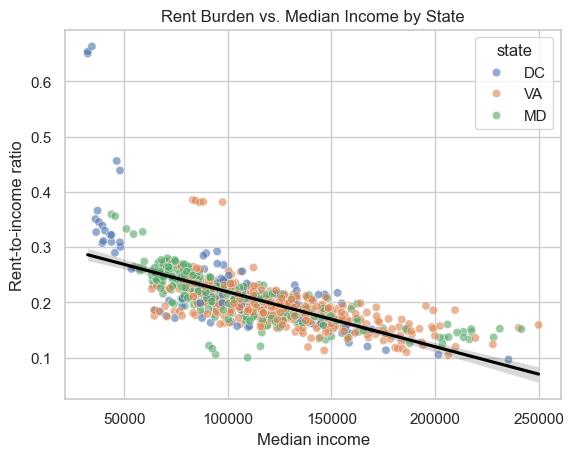

In [27]:
sns.scatterplot(data=model_df, x="median_income", y="rent_to_income", hue="state", alpha=0.6)
sns.regplot(data=model_df, x="median_income", y="rent_to_income", scatter=False, color="black")
plt.title("Rent Burden vs. Median Income by State")
plt.xlabel("Median income")
plt.ylabel("Rent-to-income ratio")
plt.show()

## Baseline OLS Model

This model ignores state differences and treats all DMV ZIP-year observations as one pooled sample.

In [34]:
baseline_ols = smf.ols(
    "rent_to_income ~ poverty_rate_z + pct_bachelors_plus_z + pct_renter_z + pct_white_z + pct_black_z + pct_hispanic_z + pct_asian_z + pct_under18_z + pct_elderly_z + C(year)",
      data=model_df).fit()
baseline_ols.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:         rent_to_income   R-squared:                       0.697
Model:                            OLS   Adj. R-squared:                  0.692
Method:                 Least Squares   F-statistic:                     144.1
Date:                Sun, 19 Apr 2026   Prob (F-statistic):          5.51e-201
Time:                        21:04:34   Log-Likelihood:                 1764.2
No. Observations:                 830   AIC:                            -3500.
Df Residuals:                     816   BIC:                            -3434.
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
========================================================================================
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept                0.2086      0.002     90.092      0.000       0.204       0.213
C(year)[T.2019]         -0.0021      0.003     -0.646      0.519      -0.008       0.004
C(year)[T.2020]         -0.0023      0.003     -0.700      0.484      -0.009       0.004
C(year)[T.2021]         -0.0036      0.003     -1.100      0.272      -0.010       0.003
C(year)[T.2022]         -0.0054      0.003     -1.574      0.116      -0.012       0.001
poverty_rate_z           0.0150      0.002      9.307      0.000       0.012       0.018
pct_bachelors_plus_z    -0.0206      0.002    -10.881      0.000      -0.024      -0.017
pct_renter_z             0.0257      0.002     15.352      0.000       0.022       0.029
pct_white_z             -0.0628      0.020     -3.196      0.001      -0.101      -0.024
pct_black_z             -0.0617      0.020     -3.076      0.002      -0.101      -0.022
pct_hispanic_z          -0.0330      0.010     -3.461      0.001      -0.052      -0.014
pct_asian_z             -0.0145      0.008     -1.857      0.064      -0.030       0.001
pct_under18_z           -0.0069      0.002     -4.574      0.000      -0.010      -0.004
pct_elderly_z           -0.0008      0.001     -0.701      0.483      -0.003       0.002
==============================================================================
Omnibus:                      531.745   Durbin-Watson:                   1.880
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            13531.104
Skew:                           2.462   Prob(JB):                         0.00
Kurtosis:                      22.158   Cond. No.                         52.8
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

## State Fixed Effects Model

This model shows whether DC, MD, and VA have different baseline rent burden levels after controlling for the other variables.

In [29]:
state_fixed_ols = smf.ols(
    "rent_to_income ~ poverty_rate_z + pct_bachelors_plus_z + pct_renter_z + pct_white_z + pct_black_z + pct_hispanic_z + pct_asian_z + pct_under18_z + pct_elderly_z + C(year) + C(state)",
    data=model_df
).fit()

state_fixed_ols.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:         rent_to_income   R-squared:                       0.700
Model:                            OLS   Adj. R-squared:                  0.695
Method:                 Least Squares   F-statistic:                     126.8
Date:                Sun, 19 Apr 2026   Prob (F-statistic):          4.92e-201
Time:                        21:01:08   Log-Likelihood:                 1769.4
No. Observations:                 830   AIC:                            -3507.
Df Residuals:                     814   BIC:                            -3431.
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
========================================================================================
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept                0.2008      0.005     43.638      0.000       0.192       0.210
C(year)[T.2019]         -0.0019      0.003     -0.593      0.553      -0.008       0.004
C(year)[T.2020]         -0.0019      0.003     -0.599      0.549      -0.008       0.004
C(year)[T.2021]         -0.0034      0.003     -1.040      0.299      -0.010       0.003
C(year)[T.2022]         -0.0050      0.003     -1.483      0.138      -0.012       0.002
C(state)[T.MD]           0.0122      0.005      2.641      0.008       0.003       0.021
C(state)[T.VA]           0.0060      0.005      1.252      0.211      -0.003       0.015
poverty_rate_z           0.0172      0.002      8.831      0.000       0.013       0.021
pct_bachelors_plus_z    -0.0185      0.002     -8.489      0.000      -0.023      -0.014
pct_renter_z             0.0254      0.002     14.814      0.000       0.022       0.029
pct_white_z             -0.0606      0.020     -3.091      0.002      -0.099      -0.022
pct_black_z             -0.0603      0.020     -3.003      0.003      -0.100      -0.021
pct_hispanic_z          -0.0327      0.010     -3.432      0.001      -0.051      -0.014
pct_asian_z             -0.0143      0.008     -1.837      0.067      -0.030       0.001
pct_under18_z           -0.0065      0.002     -4.320      0.000      -0.010      -0.004
pct_elderly_z           -0.0017      0.001     -1.357      0.175      -0.004       0.001
==============================================================================
Omnibus:                      519.877   Durbin-Watson:                   1.885
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            12495.939
Skew:                           2.402   Prob(JB):                         0.00
Kurtosis:                      21.392   Cond. No.                         53.6
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

## Poverty-by-State Interaction Model

This model shows whether the relationship between poverty rate and rent burden is different across DC, MD, and VA.

In [30]:
interaction_ols = smf.ols(
    "rent_to_income ~ poverty_rate_z * C(state) + pct_bachelors_plus_z + pct_renter_z + pct_white_z + pct_black_z + pct_hispanic_z + pct_asian_z + pct_under18_z + pct_elderly_z + C(year)",
    data=model_df
).fit()

interaction_ols.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:         rent_to_income   R-squared:                       0.754
Model:                            OLS   Adj. R-squared:                  0.749
Method:                 Least Squares   F-statistic:                     146.4
Date:                Sun, 19 Apr 2026   Prob (F-statistic):          1.91e-233
Time:                        21:01:08   Log-Likelihood:                 1851.2
No. Observations:                 830   AIC:                            -3666.
Df Residuals:                     812   BIC:                            -3581.
Df Model:                          17                                         
Covariance Type:            nonrobust                                         
=================================================================================================
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept                         0.1806      0.004     40.637      0.000       0.172       0.189
C(state)[T.MD]                    0.0317      0.004      7.104      0.000       0.023       0.040
C(state)[T.VA]                    0.0231      0.005      5.066      0.000       0.014       0.032
C(year)[T.2019]                  -0.0031      0.003     -1.063      0.288      -0.009       0.003
C(year)[T.2020]                  -0.0041      0.003     -1.400      0.162      -0.010       0.002
C(year)[T.2021]                  -0.0051      0.003     -1.711      0.088      -0.011       0.001
C(year)[T.2022]                  -0.0071      0.003     -2.312      0.021      -0.013      -0.001
poverty_rate_z                    0.0309      0.002     15.094      0.000       0.027       0.035
poverty_rate_z:C(state)[T.MD]    -0.0332      0.003    -10.859      0.000      -0.039      -0.027
poverty_rate_z:C(state)[T.VA]    -0.0353      0.003    -12.042      0.000      -0.041      -0.030
pct_bachelors_plus_z             -0.0175      0.002     -8.831      0.000      -0.021      -0.014
pct_renter_z                      0.0297      0.002     18.702      0.000       0.027       0.033
pct_white_z                      -0.0751      0.018     -4.177      0.000      -0.110      -0.040
pct_black_z                      -0.0745      0.018     -4.047      0.000      -0.111      -0.038
pct_hispanic_z                   -0.0322      0.009     -3.680      0.000      -0.049      -0.015
pct_asian_z                      -0.0220      0.007     -3.070      0.002      -0.036      -0.008
pct_under18_z                    -0.0078      0.001     -5.647      0.000      -0.010      -0.005
pct_elderly_z                     0.0008      0.001      0.696      0.487      -0.001       0.003
==============================================================================
Omnibus:                      362.190   Durbin-Watson:                   1.922
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             3821.622
Skew:                           1.687   Prob(JB):                         0.00
Kurtosis:                      12.956   Cond. No.                         55.0
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

## Mixed-Effects Model

This is the multilevel model. ZIP-year observations are grouped by state, allowing each state to have its own baseline rent burden level.

In [ ]:
mixed_intercept = smf.mixedlm(
    "rent_to_income ~ poverty_rate_z + pct_bachelors_plus_z + pct_renter_z + pct_white_z + pct_black_z + pct_hispanic_z + pct_asian_z + pct_under18_z + pct_elderly_z + C(year)",
    data=model_df,
    groups=model_df["state"]
).fit(reml=False, method="lbfgs")

mixed_intercept.summary()


c:\Users\erinb\miniconda3\envs\dsan5300-tf\lib\site-packages\statsmodels\regression\mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
c:\Users\erinb\miniconda3\envs\dsan5300-tf\lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


<class 'statsmodels.iolib.summary2.Summary'>
"""
             Mixed Linear Model Regression Results
===============================================================
Model:             MixedLM  Dependent Variable:  rent_to_income
No. Observations:  830      Method:              ML            
No. Groups:        3        Scale:               0.0008        
Min. group size:   110      Log-Likelihood:      1765.3797     
Max. group size:   410      Converged:           Yes           
Mean group size:   276.7                                       
---------------------------------------------------------------
                     Coef.  Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------------
Intercept             0.208    0.003 68.147 0.000  0.202  0.214
C(year)[T.2019]      -0.002    0.003 -0.620 0.535 -0.008  0.004
C(year)[T.2020]      -0.002    0.003 -0.646 0.518 -0.008  0.004
C(year)[T.2021]      -0.003    0.003 -1.068 0.286 -0.010  0.003
C(year)[T.2022]      -0.005    0.003 -1.522 0.128 -0.012  0.001
poverty_rate_z        0.016    0.002  8.417 0.000  0.012  0.020
pct_bachelors_plus_z -0.020    0.002 -9.271 0.000 -0.024 -0.016
pct_renter_z          0.026    0.002 15.275 0.000  0.022  0.029
pct_white_z          -0.062    0.019 -3.193 0.001 -0.100 -0.024
pct_black_z          -0.062    0.020 -3.112 0.002 -0.101 -0.023
pct_hispanic_z       -0.033    0.009 -3.521 0.000 -0.052 -0.015
pct_asian_z          -0.015    0.008 -1.880 0.060 -0.030  0.001
pct_under18_z        -0.007    0.002 -4.407 0.000 -0.010 -0.004
pct_elderly_z        -0.001    0.001 -1.135 0.257 -0.004  0.001
Group Var             0.000    0.000                           
===============================================================

"""

## Model Comparison

The poverty by state interaction is the best model, suggesting that poverty rate and rent burden duffers across DC, MD, and VA.

In [32]:
comparison_rows = [
    ("Baseline OLS", baseline_ols),
    ("State fixed effects OLS", state_fixed_ols),
    ("Poverty-by-state interaction OLS", interaction_ols),
    ("Mixed effects: random state intercept", mixed_intercept),
]

comparison = pd.DataFrame([
    {"model": name, "aic": model.aic, "bic": model.bic}
    for name, model in comparison_rows
])

comparison.round(2)


,model,aic,bic
0,Baseline OLS,-3500.42,-3434.32
1,State fixed effects OLS,-3506.86,-3431.31
2,Poverty-by-state interaction OLS,-3666.45,-3581.47
3,Mixed effects: random state intercept,-3498.76,-3423.22


# Plot Exploring Poverty Rate and Rent Burden Across Regions

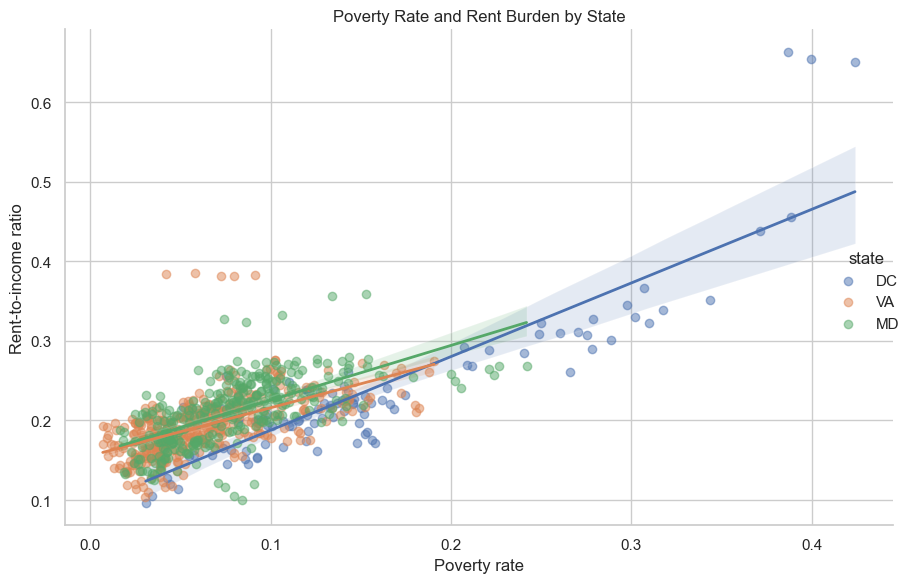

In [ ]:
sns.lmplot(
    data=model_df,
    x="poverty_rate",
    y="rent_to_income",
    hue="state",
    height=6,
    aspect=1.4,
    scatter_kws={"alpha": 0.5},
    line_kws={"linewidth": 2}
)

plt.title("Poverty Rate and Rent Burden by State")
plt.xlabel("Poverty rate")
plt.ylabel("Rent-to-income ratio")
plt.show()


This analysis demonstrates that the effect of poverty rate differs across states, not just that states have different average rent burden levels.